Import necessary packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import mne

Load configurations

In [2]:
from aad_trf.utils import *
config_id = 'classifier-010'
config = load_config(config_id)
config_id_trf = config['config_id_trf']
config_trf = load_config(config_id_trf)
dataset_name = config_trf['dataset']
base_path = "/Users/jusungham/HANG/aad-trf/"
path_dict = set_paths_from_config(base_path, config_trf)
model_name = config['model_name']

Load classification results of Logistic Regression

In [3]:
clf_results_by_trial_filename = f"dataset-{dataset_name}_reports-clf-results-by-trial_models-{model_name}_config-{config_id}"
results_df_lr = pd.read_csv(os.path.join(path_dict['reports'], clf_results_by_trial_filename + ".csv"))

Load classification results of SVC

In [4]:
config_id = 'classifier-011'
config = load_config(config_id)
model_name = config['model_name']
clf_results_by_trial_filename = f"dataset-{dataset_name}_reports-clf-results-by-trial_models-{model_name}_config-{config_id}"
results_df_svc = pd.read_csv(os.path.join(path_dict['reports'], clf_results_by_trial_filename + ".csv"))

In [5]:
eeg_data_filename = f"dataset-{dataset_name}_data-eeg_config-eeg-002_-epo.fif"
epochs = mne.read_epochs(os.path.join(path_dict['features'], eeg_data_filename))

Reading /Users/jusungham/HANG/aad-trf/data/features/dataset-updown-nh_data-eeg_config-eeg-002_-epo.fif ...
    Found the data of interest:
        t =    1000.00 ...    4484.38 ms
        0 CTF compensation matrices available
Adding metadata with 1 columns
3211 matching events found
No baseline correction applied
0 projection items activated


In [6]:
eeg = epochs.get_data()
# eeg = (eeg - np.mean(eeg, axis=2, keepdims=True)) / np.std(eeg, axis=2, keepdims=True)
trial_fingerprints = eeg[:,0,0]
# trial_fingerprints = np.round(trial_fingerprints, 4)

/var/folders/lx/1nly0g_s00s707fn8r7zjjch0000gn/T/ipykernel_2787/4197963171.py:1: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  eeg = epochs.get_data()


In [7]:
results_df_lr['trial_fingerprint'] = trial_fingerprints
results_df_svc['trial_fingerprint'] = trial_fingerprints

In [8]:
model_name = 'cnn'
clf_results_by_trial_filename = f"dataset-{dataset_name}_reports-clf-results-by-trial_models-{model_name}_config-004"
results_df_cnn = pd.read_csv(os.path.join(path_dict['reports'], clf_results_by_trial_filename + ".csv"))
results_df_cnn['label'] = 1 - results_df_cnn['label']
results_df_cnn['prediction'] = results_df_cnn['label'] & results_df_cnn['correct']
results_df_cnn['prediction'] = results_df_cnn['prediction'].astype(int)
results_df_cnn = results_df_cnn.rename(columns={'SubID': 'sub_id'})

In [9]:
model_name = 'cnn'
clf_results_by_trial_filename = f"dataset-{dataset_name}_reports-clf-results-by-trial_models-{model_name}_config-005"
results_df_cnn2 = pd.read_csv(os.path.join(path_dict['reports'], clf_results_by_trial_filename + ".csv"))
results_df_cnn2['prediction'] = results_df_cnn2['label'] & results_df_cnn2['correct']
results_df_cnn2['prediction'] = results_df_cnn2['prediction'].astype(int)
results_df_cnn2 = results_df_cnn2.rename(columns={'SubID': 'sub_id'})

Caculate prediction agreement between two models

In [10]:
prediction_lr = results_df_lr['prediction'].astype(bool)
prediction_svc = results_df_svc['prediction'].astype(bool)
prediction_cnn = results_df_cnn['prediction'].astype(bool)
prediction_cnn2 = results_df_cnn2['prediction'].astype(bool)

In [11]:
agreement = prediction_lr == prediction_svc
print(f"agreement rate: {agreement.mean():.2f}")
agreement = prediction_lr == prediction_cnn
print(f"agreement rate: {agreement.mean():.2f}")
agreement = prediction_lr == prediction_cnn2
print(f"agreement rate: {agreement.mean():.2f}")
agreement = prediction_svc == prediction_cnn
print(f"agreement rate: {agreement.mean():.2f}")
agreement = prediction_svc == prediction_cnn2
print(f"agreement rate: {agreement.mean():.2f}")
agreement = prediction_cnn == prediction_cnn2
print(f"agreement rate: {agreement.mean():.2f}")
agreement_all = np.all(np.stack([prediction_lr, prediction_svc, prediction_cnn, prediction_cnn2]), axis=0) | np.all(~np.stack([prediction_lr, prediction_svc, prediction_cnn, prediction_cnn2]), axis=0)
print(f"agreement rate among all four models: {agreement_all.mean():.2f}")


agreement rate: 0.87
agreement rate: 0.68
agreement rate: 0.67
agreement rate: 0.67
agreement rate: 0.66
agreement rate: 0.91
agreement rate among all four models: 0.56


Cohen's Kappa
> If the raters are in complete agreement then $\textstyle \kappa =1$. If there is no agreement among the raters other than what would be expected by chance, $\textstyle \kappa =0$. It is possible for the statistic to be negative, which can occur by chance if there is no relationship between the ratings of the two raters, or it may reflect a real tendency of the raters to give differing ratings.
> 
> https://en.wikipedia.org/wiki/Cohen%27s_kappa

In [12]:
from sklearn.metrics import cohen_kappa_score
kappa = cohen_kappa_score(prediction_lr, prediction_svc)
print(f"Cohen's Kappa: {kappa:.4f}")
kappa = cohen_kappa_score(prediction_lr, prediction_cnn)
print(f"Cohen's Kappa: {kappa:.4f}")
kappa = cohen_kappa_score(prediction_lr, prediction_cnn2)
print(f"Cohen's Kappa: {kappa:.4f}")
kappa = cohen_kappa_score(prediction_svc, prediction_cnn)
print(f"Cohen's Kappa: {kappa:.4f}")
kappa = cohen_kappa_score(prediction_svc, prediction_cnn2)
print(f"Cohen's Kappa: {kappa:.4f}")
kappa = cohen_kappa_score(prediction_cnn, prediction_cnn2)
print(f"Cohen's Kappa: {kappa:.4f}")

Cohen's Kappa: 0.7364
Cohen's Kappa: 0.3563
Cohen's Kappa: 0.3322
Cohen's Kappa: 0.3299
Cohen's Kappa: 0.3069
Cohen's Kappa: 0.8015


In [13]:
from statsmodels.stats.inter_rater import aggregate_raters, fleiss_kappa

# Create a matrix of ratings
prediction_lr = results_df_lr['prediction'].astype(int)
prediction_svc = results_df_svc['prediction'].astype(int)
prediction_cnn = results_df_cnn['prediction'].astype(int)
prediction_cnn2 = results_df_cnn2['prediction'].astype(int)
ratings = np.array([prediction_lr, prediction_svc, prediction_cnn, prediction_cnn2]).T

# Convert predictions to counts for each rating category
rating_counts = np.zeros((ratings.shape[0], 2), dtype=int)
for i in range(ratings.shape[0]):
	unique, counts = np.unique(ratings[i], return_counts=True)
	rating_counts[i, unique] = counts

# Calculate Fleiss' Kappa
fleiss_kappa_value = fleiss_kappa(rating_counts, method='fleiss')
print(f"Fleiss' Kappa: {fleiss_kappa_value:.4f}")

Fleiss' Kappa: 0.4704



| Model Pairs | Cohen's (Fleiss') Kappa Value |
|---|---|
| LR & SVC | 0.7364 |
| LR & CNN | 0.3563 |
| SVC & CNN | 0.3299 |
| LR & SVC & CNN | 0.4711 |


Calculate the number of common trials both models correctly classified

In [14]:
correct_lr = results_df_lr['correct']
correct_svc = results_df_svc['correct']
correct_cnn = results_df_cnn['correct'].astype(bool)
correct_cnn2 = results_df_cnn2['correct'].astype(bool)
agreement_correct = correct_lr == correct_svc
print(f"agreement rate (correct): {agreement_correct.mean():.2f}")
agreement_correct = correct_lr == correct_cnn
print(f"agreement rate (correct): {agreement_correct.mean():.2f}")
agreement_correct = correct_lr == correct_cnn2
print(f"agreement rate (correct): {agreement_correct.mean():.2f}")
agreement_correct = correct_svc == correct_cnn
print(f"agreement rate (correct): {agreement_correct.mean():.2f}")
agreement_correct = correct_svc == correct_cnn2
print(f"agreement rate (correct): {agreement_correct.mean():.2f}")
agreement_correct = correct_cnn == correct_cnn2
print(f"agreement rate (correct): {agreement_correct.mean():.2f}")
agreement_correct_all = np.all(np.stack([correct_lr, correct_svc, correct_cnn, correct_cnn2]), axis=0) | np.all(~np.stack([correct_lr, correct_svc, correct_cnn, correct_cnn2]), axis=0)
print(f"agreement rate among all four models (correct): {agreement_correct_all.mean():.2f}")

agreement rate (correct): 0.87
agreement rate (correct): 0.70
agreement rate (correct): 0.66
agreement rate (correct): 0.68
agreement rate (correct): 0.66
agreement rate (correct): 0.82
agreement rate among all four models (correct): 0.53


According to the result, 87% of trials (2788) are classified correctly in both models. 7% of trials were classified correctly on logistic regression. 6% of trials were classified correctly on SVM. 

/Users/jusungham/miniconda3/envs/aad-trf/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/Users/jusungham/miniconda3/envs/aad-trf/lib/python3.12/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which w

{'matrix': <Axes: >,
 'shading': <Axes: >,
 'totals': <Axes: >,
 'intersections': <Axes: ylabel='Intersection size'>}

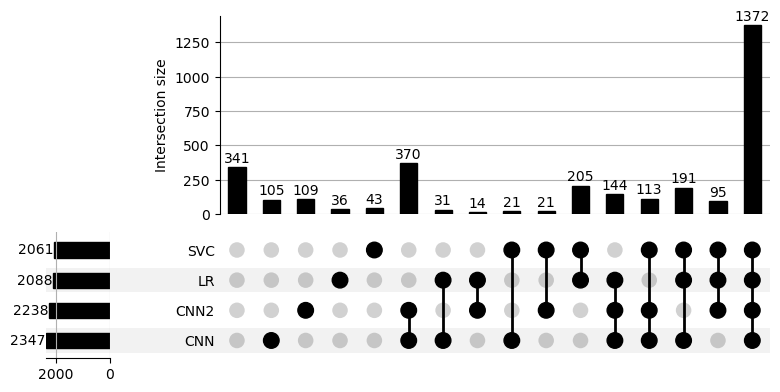

In [15]:
from upsetplot import from_indicators, UpSet
correct_df = pd.DataFrame({'LR': correct_lr, 'SVC': correct_svc, 'CNN': correct_cnn, 'CNN2': correct_cnn2})
correct_by_model = from_indicators(correct_df)
upset = UpSet(correct_by_model, subset_size='count', orientation='horizontal', show_counts='%d')
upset.plot()

In [16]:
correct_all = correct_lr & correct_svc & correct_cnn & correct_cnn2
incorrect_all = ~correct_lr & ~correct_svc & ~correct_cnn & ~correct_cnn2
correct_all_idx = correct_all[correct_all].index
incorrect_all_idx = incorrect_all[incorrect_all].index
correct_all_idx_sample = np.random.choice(correct_all_idx, len(incorrect_all_idx), replace=False)

In [17]:
# get index of correct trials
correct_true_lr = correct_lr[correct_lr]
correct_idx_lr = correct_true_lr.sample(n=len(results_df_lr) - sum(correct_lr), random_state=42).index
correct_true_svc = correct_svc[correct_svc]
correct_idx_svc = correct_true_svc.sample(n=len(results_df_svc) - sum(correct_svc), random_state=42).index
correct_true_cnn = correct_cnn[correct_cnn]
correct_idx_cnn = correct_true_cnn.sample(n=len(results_df_cnn) - sum(correct_cnn), random_state=42).index
correct_true_cnn2 = correct_cnn2[correct_cnn2]
correct_idx_cnn2 = correct_true_cnn2.sample(n=len(results_df_cnn2) - sum(correct_cnn2), random_state=42).index

In [18]:
# load AAD_dataset
from aad_trf.aad_dataset import AAD_Dataset
config_id_audio = 'audio-001'
config_id_eeg = 'eeg-002'
audio_filename = f"dataset-{dataset_name}_data-audio_config-{config_id_audio}"
audio = np.load(os.path.join(path_dict['features'], f"{audio_filename}.npy"))
eeg_filename = f"dataset-{dataset_name}_data-eeg_config-{config_id_eeg}_-epo"
epochs = mne.read_epochs(os.path.join(path_dict['features'], f"{eeg_filename}.fif"))
dataset = AAD_Dataset()
dataset.create(epochs, audio)
del audio, epochs

Reading /Users/jusungham/HANG/aad-trf/data/features/dataset-updown-nh_data-eeg_config-eeg-002_-epo.fif ...
    Found the data of interest:
        t =    1000.00 ...    4484.38 ms
        0 CTF compensation matrices available
Adding metadata with 1 columns
3211 matching events found
No baseline correction applied
0 projection items activated


/Users/jusungham/HANG/aad-trf/src/aad_trf/aad_dataset.py:48: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  self.eeg = eeg_epochs.get_data()


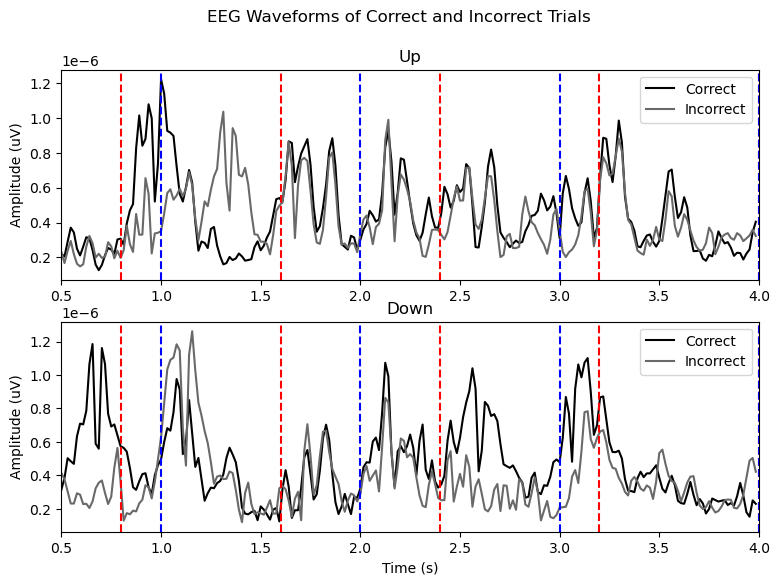

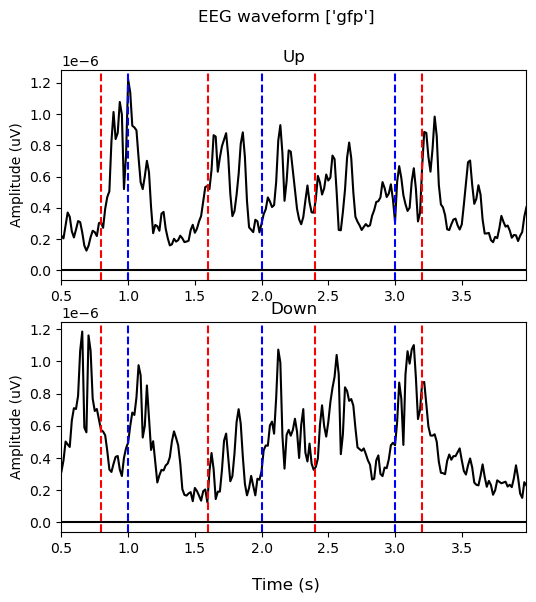

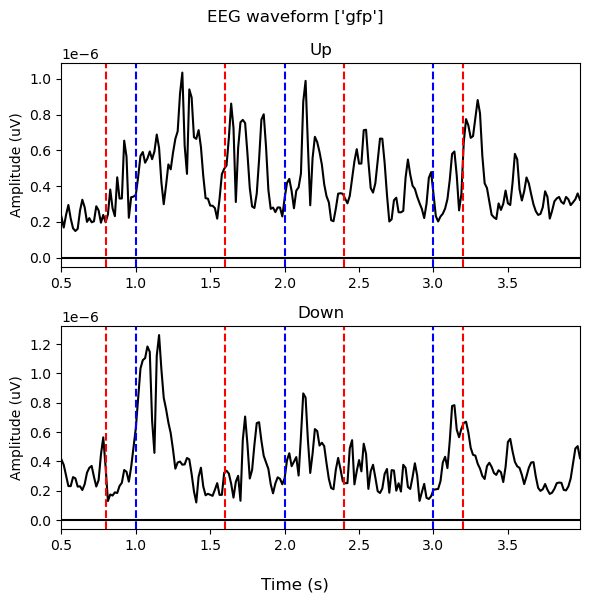

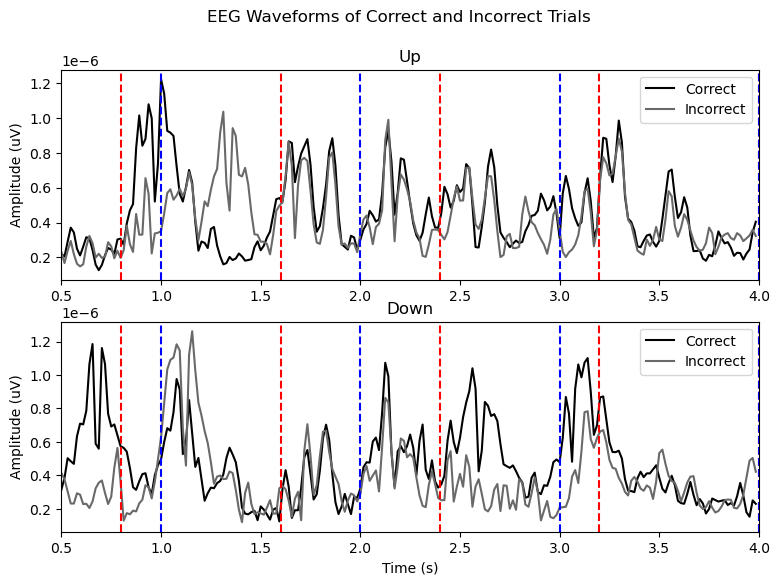

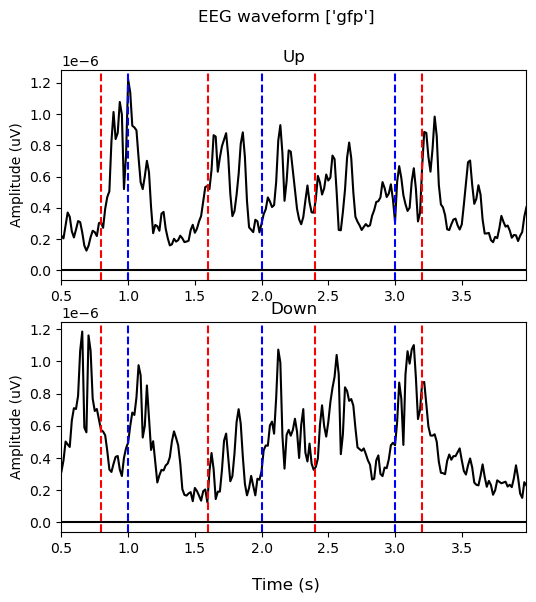

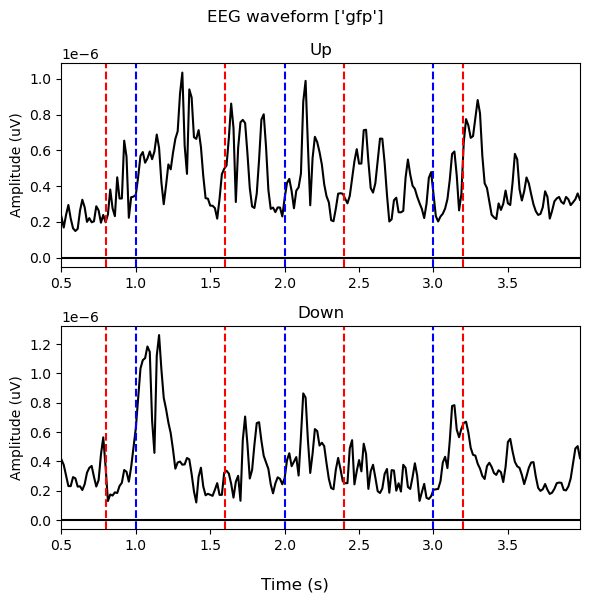

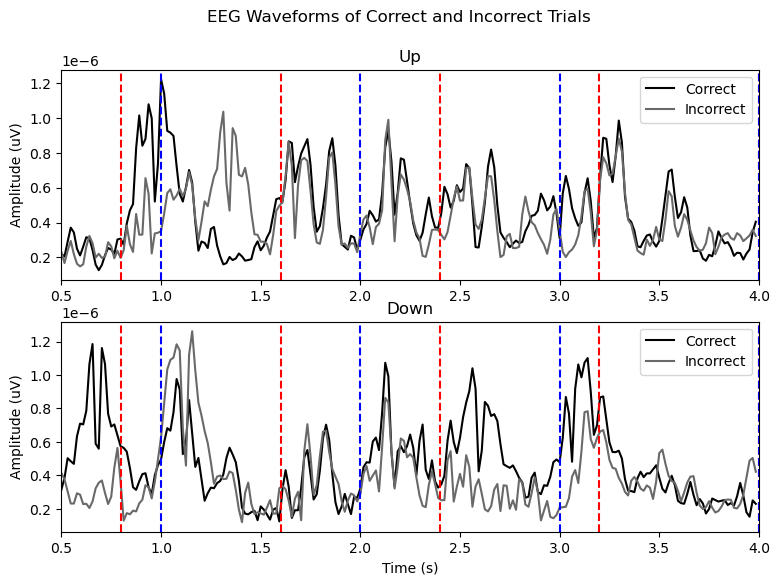

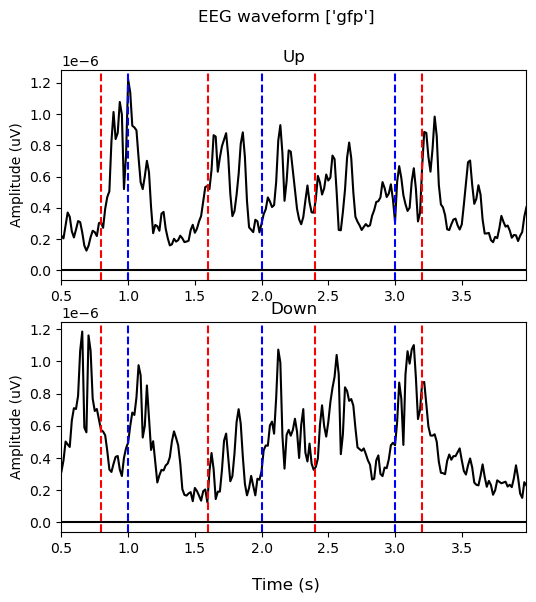

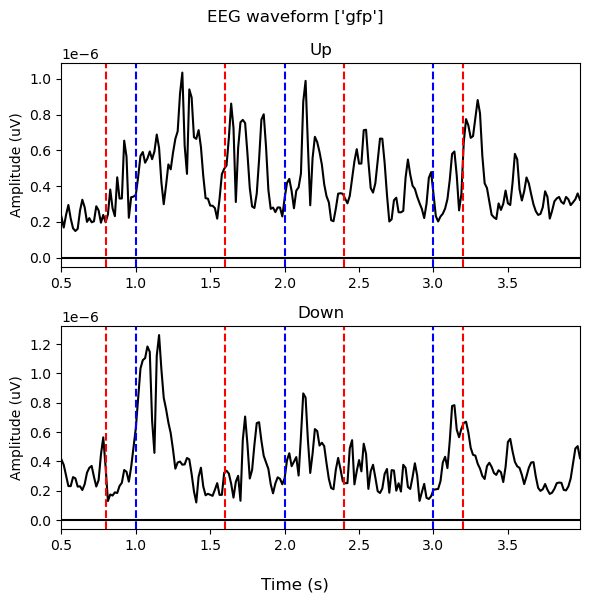

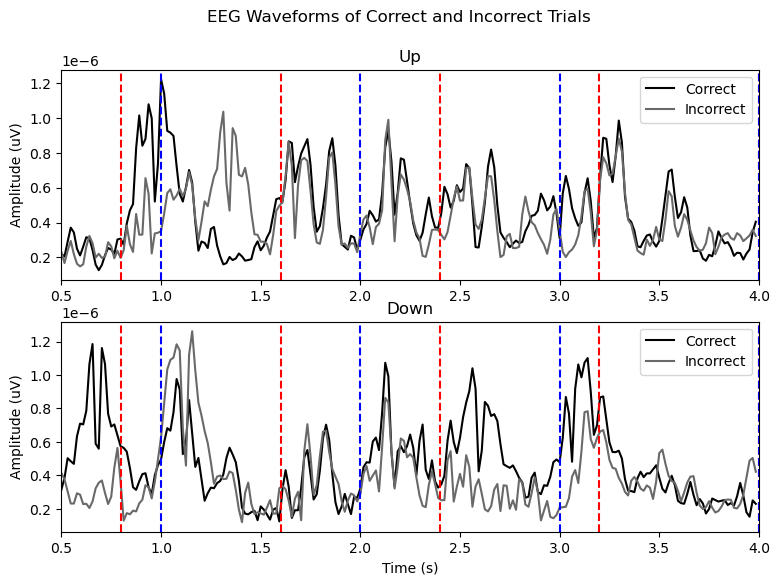

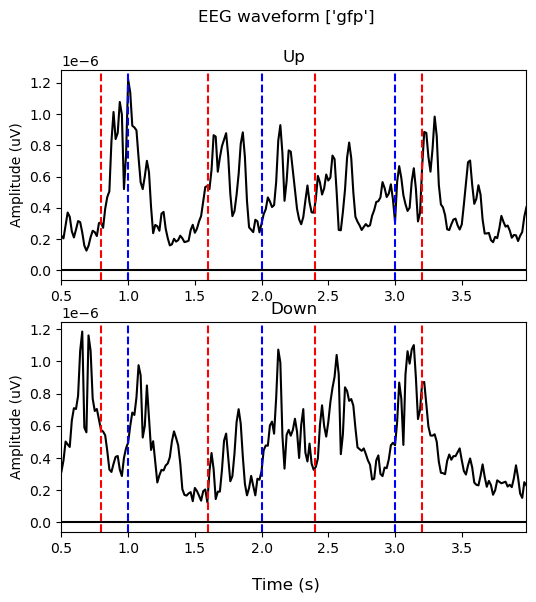

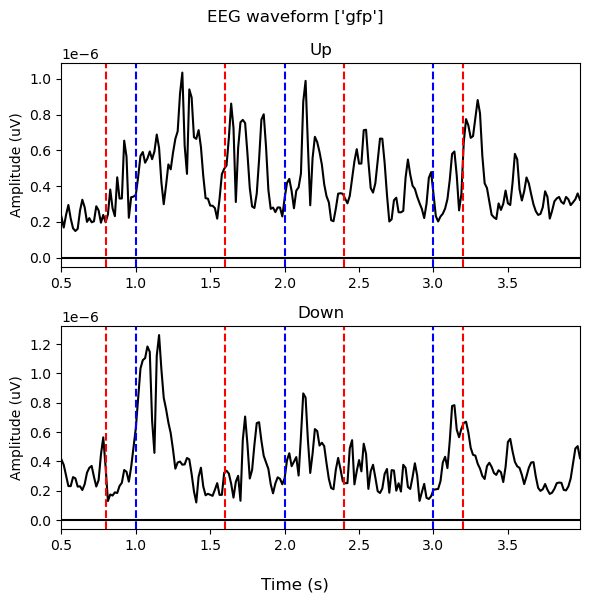

In [19]:
import matplotlib.pyplot as plt
from aad_trf.aad_plotter import plot_eeg_waveform

plot_channel = ['gfp']
for model_name in ['logistic-regression', 'svc', 'cnn', 'cnn2']:
    fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(9, 6))

    fig1, axs1 = plot_eeg_waveform(dataset[correct_idx_lr], plot_channels=plot_channel)
    line_up_correct = axs1[0].get_lines()[0]
    line_down_correct = axs1[1].get_lines()[0]
    fig2, axs2 = plot_eeg_waveform(dataset[~correct_idx_lr], plot_channels=plot_channel)
    line_up_incorrect = axs2[0].get_lines()[0]
    line_down_incorrect = axs2[1].get_lines()[0]

    ax1.plot(line_up_correct.get_xdata(), line_up_correct.get_ydata(), color='k')
    ax1.plot(line_up_incorrect.get_xdata(), line_up_incorrect.get_ydata(), color='dimgrey')
    for up_onset in np.linspace(0,4,6):
        ax1.axvline(up_onset, color='r', linestyle='--')
    for down_onset in np.linspace(0,4,5):
        ax1.axvline(down_onset, color='b', linestyle='--')
    ax1.set_title('Up')
    ax1.set_ylabel('Amplitude (uV)')
    ax1.legend(['Correct', 'Incorrect'])
    ax1.set_xlim(0.5, 4.0)

    ax2.plot(line_down_correct.get_xdata(), line_down_correct.get_ydata(), color='k')
    ax2.plot(line_down_incorrect.get_xdata(), line_down_incorrect.get_ydata(), color='dimgrey')
    for up_onset in np.linspace(0,4,6):
        ax2.axvline(up_onset, color='r', linestyle='--')
    for down_onset in np.linspace(0,4,5):
        ax2.axvline(down_onset, color='b', linestyle='--')
    ax2.set_title('Down')
    ax2.set_ylabel('Amplitude (uV)')
    ax2.set_xlabel('Time (s)')
    ax2.legend(['Correct', 'Incorrect'])
    ax2.set_xlim(0.5, 4.0)

    fig.suptitle('EEG Waveforms of Correct and Incorrect Trials')
    plt.tight_layout()
    fig_filename = f"dataset-{dataset_name}_reports-eeg-waveforms-correct-incorrect-{plot_channel[0]}_models-{model_name}.png"
    fig.savefig(os.path.join(path_dict['reports'], fig_filename), dpi=300)

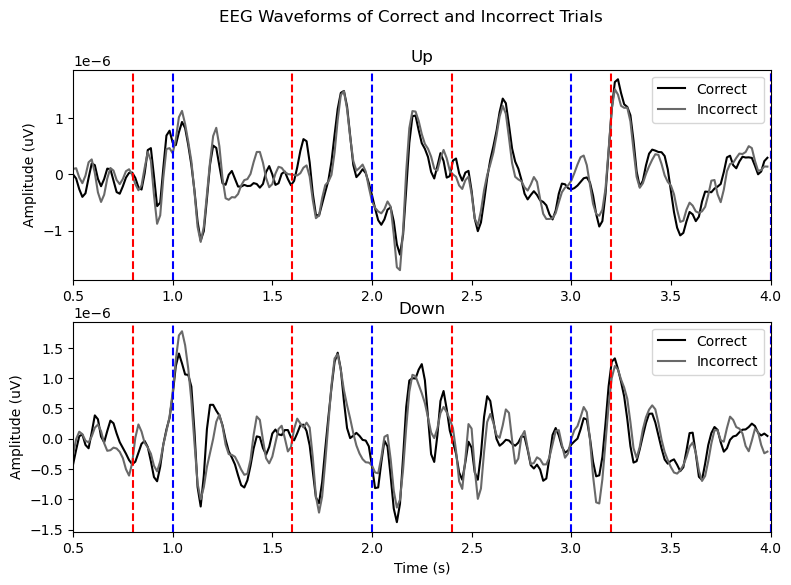

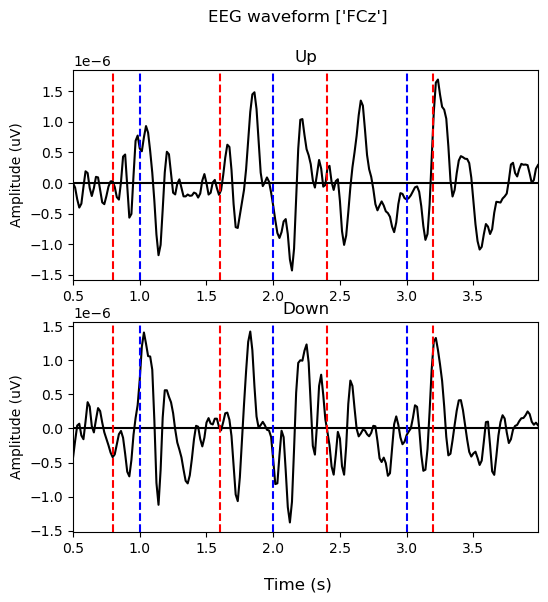

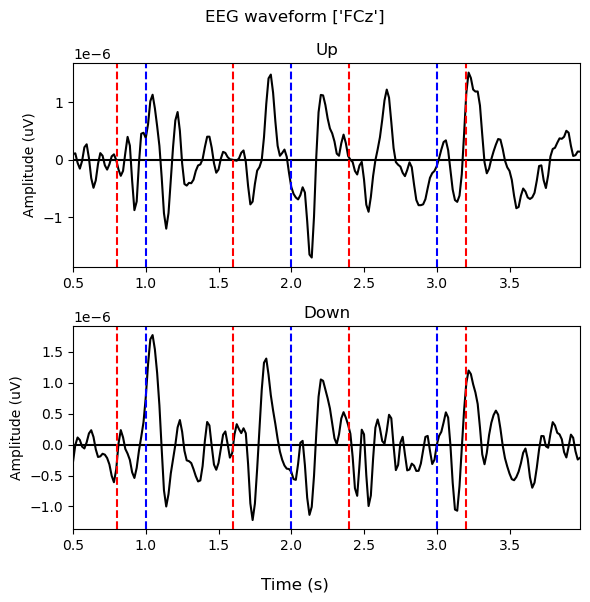

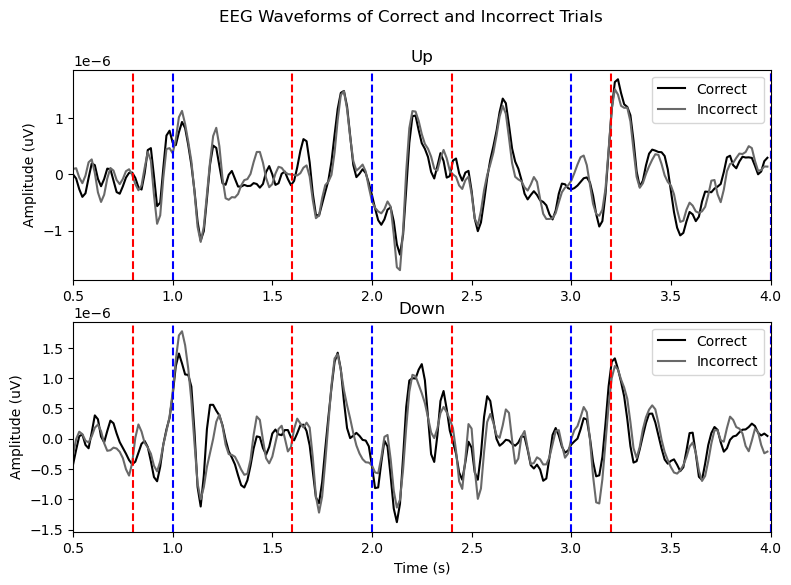

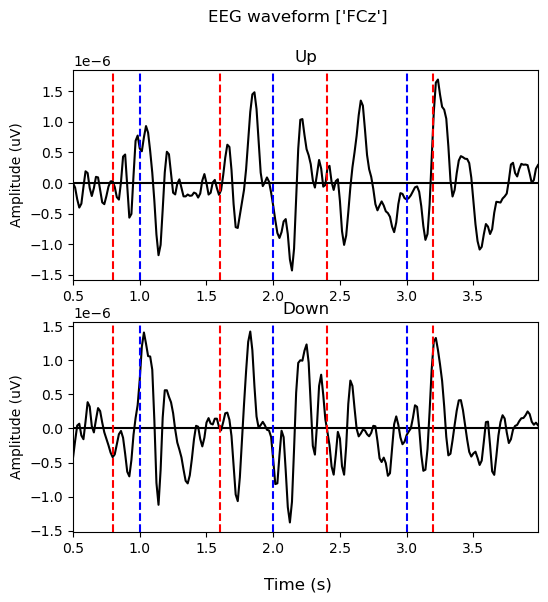

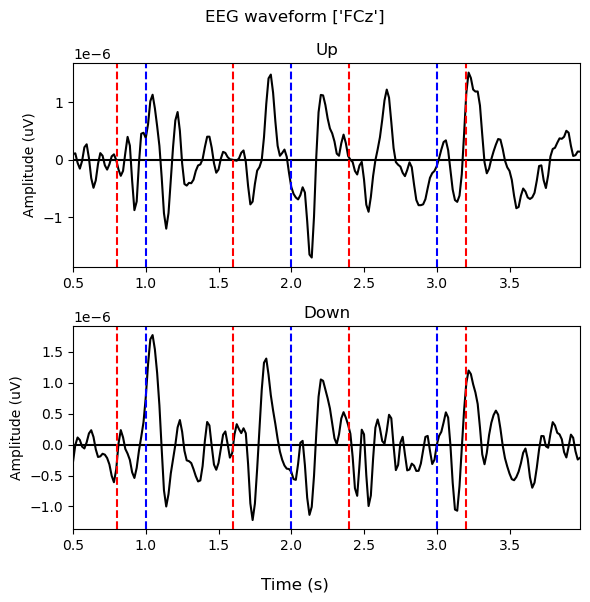

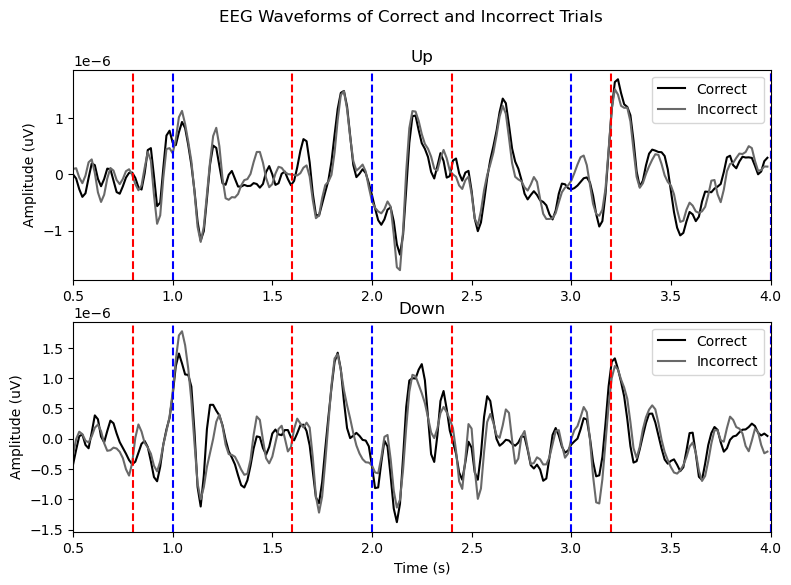

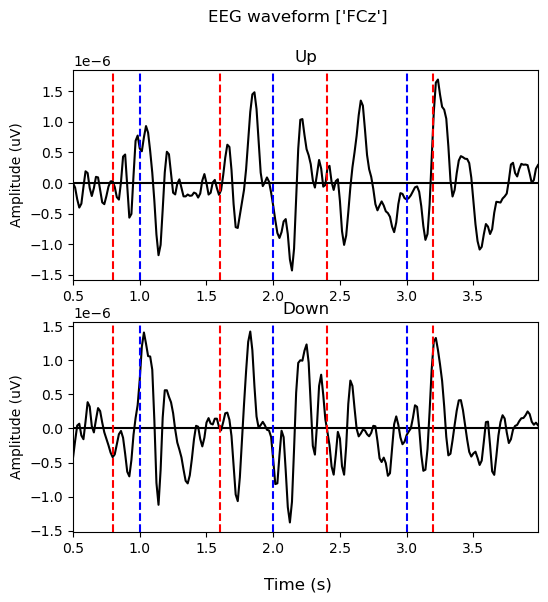

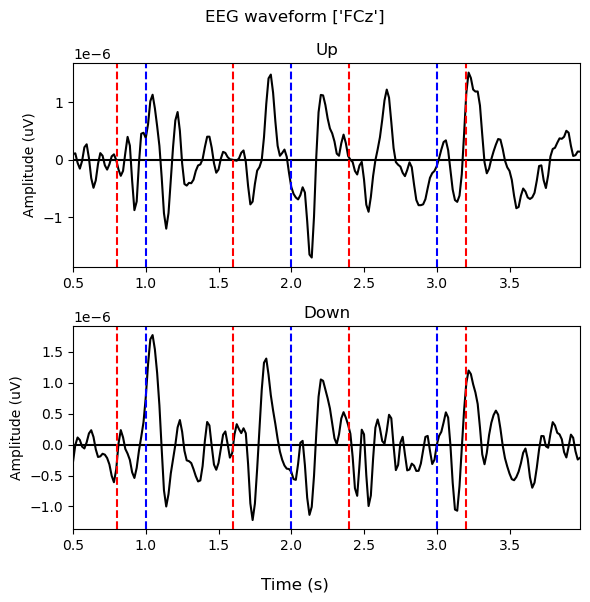

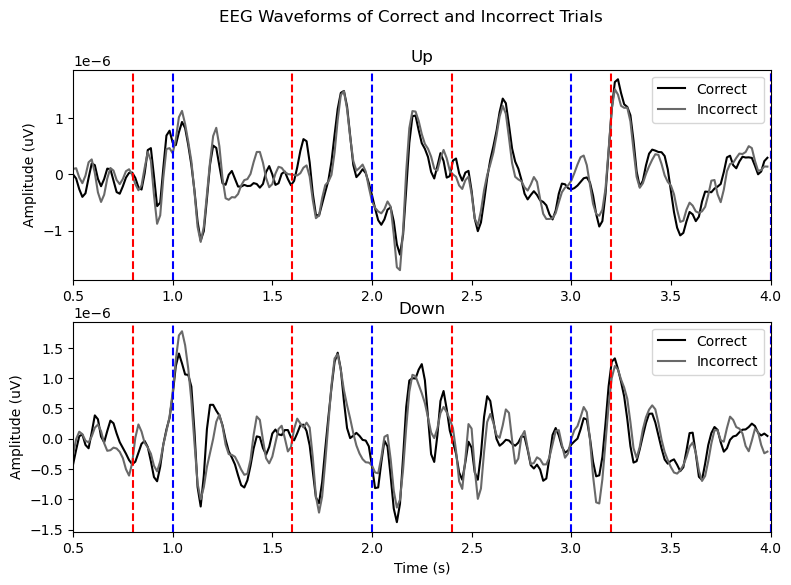

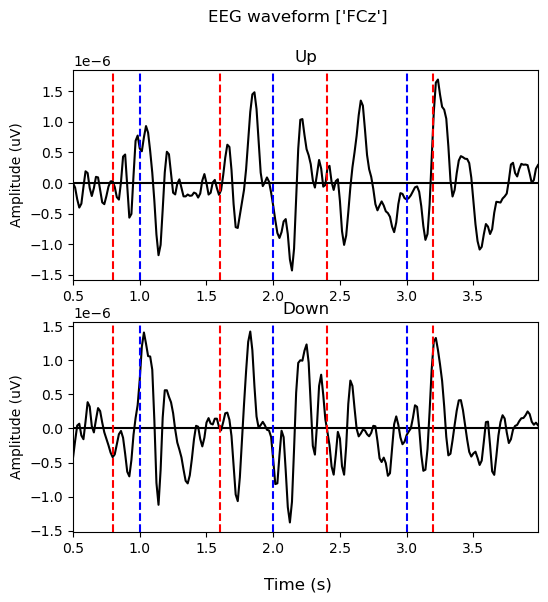

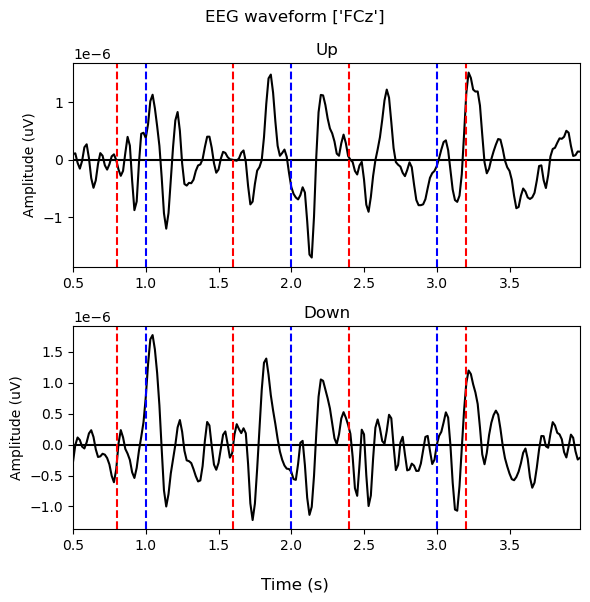

In [20]:
plot_channel = ['FCz']
for model_name in ['logistic-regression', 'svc', 'cnn', 'cnn2']:
    fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(9, 6))

    fig1, axs1 = plot_eeg_waveform(dataset[correct_idx_lr], plot_channels=plot_channel)
    line_up_correct = axs1[0].get_lines()[0]
    line_down_correct = axs1[1].get_lines()[0]
    fig2, axs2 = plot_eeg_waveform(dataset[~correct_idx_lr], plot_channels=plot_channel)
    line_up_incorrect = axs2[0].get_lines()[0]
    line_down_incorrect = axs2[1].get_lines()[0]

    ax1.plot(line_up_correct.get_xdata(), line_up_correct.get_ydata(), color='k')
    ax1.plot(line_up_incorrect.get_xdata(), line_up_incorrect.get_ydata(), color='dimgrey')
    for up_onset in np.linspace(0,4,6):
        ax1.axvline(up_onset, color='r', linestyle='--')
    for down_onset in np.linspace(0,4,5):
        ax1.axvline(down_onset, color='b', linestyle='--')
    ax1.set_title('Up')
    ax1.set_ylabel('Amplitude (uV)')
    ax1.legend(['Correct', 'Incorrect'])
    ax1.set_xlim(0.5, 4.0)

    ax2.plot(line_down_correct.get_xdata(), line_down_correct.get_ydata(), color='k')
    ax2.plot(line_down_incorrect.get_xdata(), line_down_incorrect.get_ydata(), color='dimgrey')
    for up_onset in np.linspace(0,4,6):
        ax2.axvline(up_onset, color='r', linestyle='--')
    for down_onset in np.linspace(0,4,5):
        ax2.axvline(down_onset, color='b', linestyle='--')
    ax2.set_title('Down')
    ax2.set_ylabel('Amplitude (uV)')
    ax2.set_xlabel('Time (s)')
    ax2.legend(['Correct', 'Incorrect'])
    ax2.set_xlim(0.5, 4.0)

    fig.suptitle('EEG Waveforms of Correct and Incorrect Trials')
    plt.tight_layout()
    fig_filename = f"dataset-{dataset_name}_reports-eeg-waveforms-correct-incorrect-{plot_channel[0]}_models-{model_name}.png"
    fig.savefig(os.path.join(path_dict['reports'], fig_filename), dpi=300)

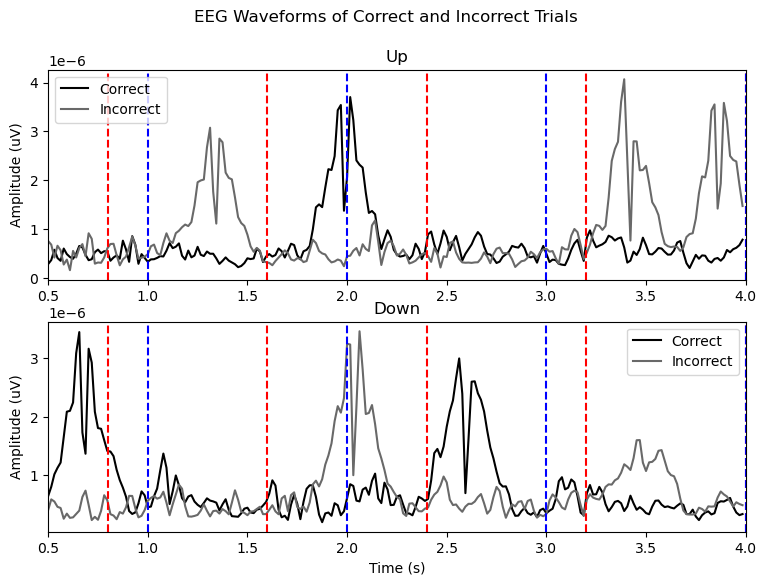

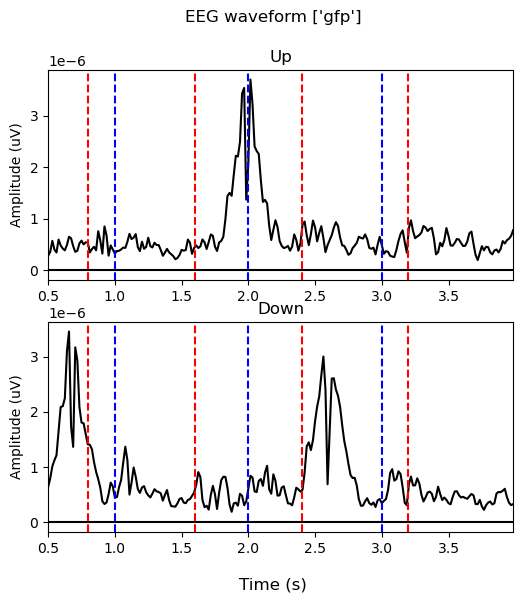

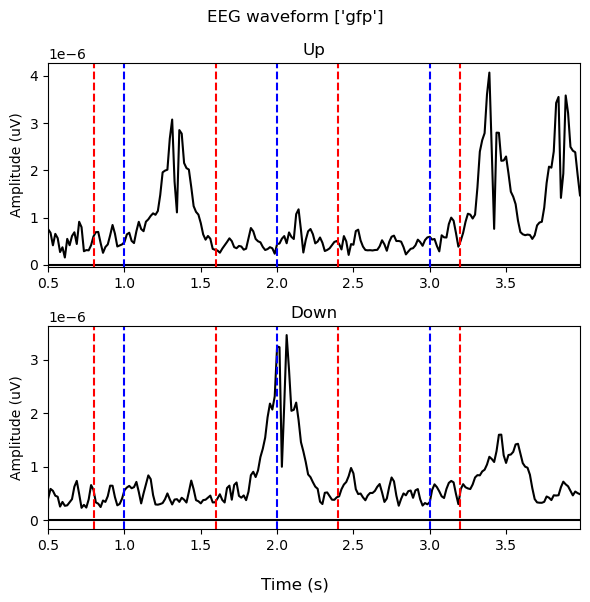

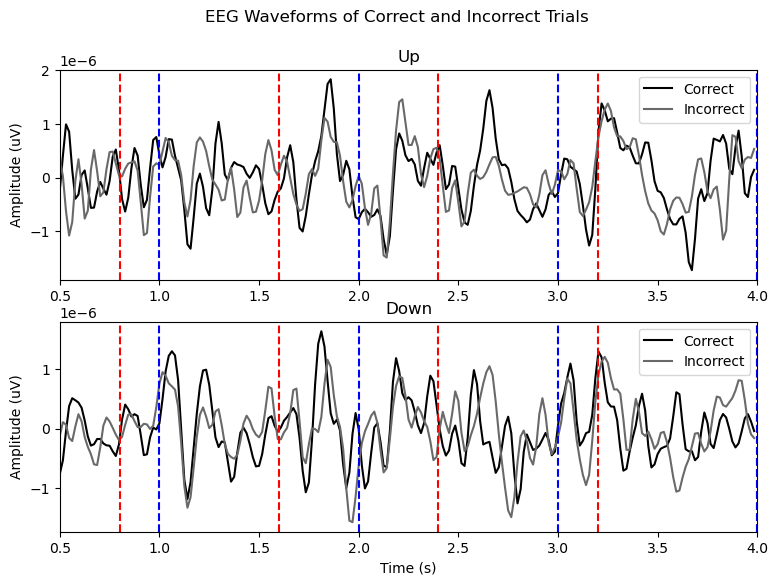

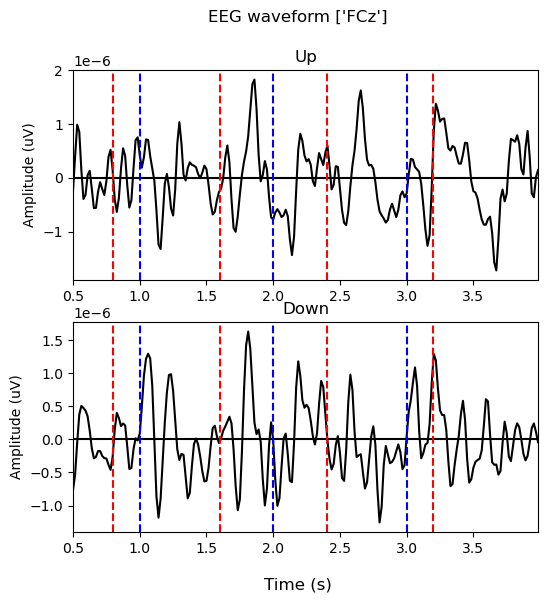

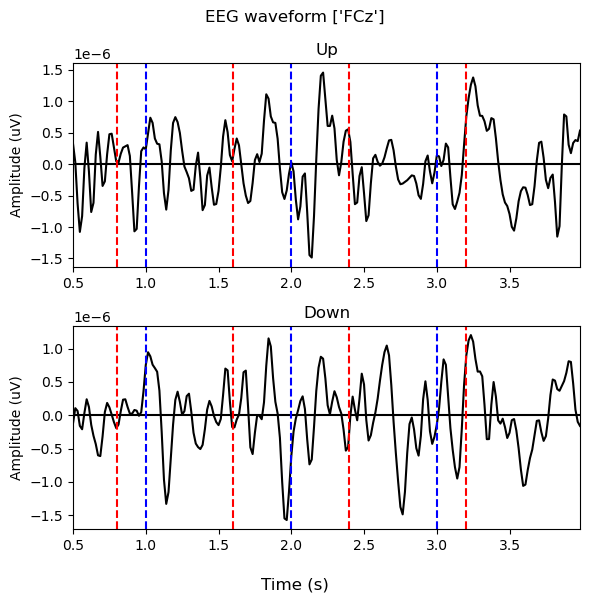

In [24]:
model_name = 'all'
for plot_channel in ['gfp', 'FCz']:
    fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(9, 6))

    fig1, axs1 = plot_eeg_waveform(dataset[correct_all_idx_sample], plot_channels=[plot_channel])
    line_up_correct = axs1[0].get_lines()[0]
    line_down_correct = axs1[1].get_lines()[0]
    fig2, axs2 = plot_eeg_waveform(dataset[incorrect_all_idx], plot_channels=[plot_channel])
    line_up_incorrect = axs2[0].get_lines()[0]
    line_down_incorrect = axs2[1].get_lines()[0]

    ax1.plot(line_up_correct.get_xdata(), line_up_correct.get_ydata(), color='k')
    ax1.plot(line_up_incorrect.get_xdata(), line_up_incorrect.get_ydata(), color='dimgrey')
    for up_onset in np.linspace(0,4,6):
        ax1.axvline(up_onset, color='r', linestyle='--')
    for down_onset in np.linspace(0,4,5):
        ax1.axvline(down_onset, color='b', linestyle='--')
    ax1.set_title('Up')
    ax1.set_ylabel('Amplitude (uV)')
    ax1.legend(['Correct', 'Incorrect'])
    ax1.set_xlim(0.5, 4.0)

    ax2.plot(line_down_correct.get_xdata(), line_down_correct.get_ydata(), color='k')
    ax2.plot(line_down_incorrect.get_xdata(), line_down_incorrect.get_ydata(), color='dimgrey')
    for up_onset in np.linspace(0,4,6):
        ax2.axvline(up_onset, color='r', linestyle='--')
    for down_onset in np.linspace(0,4,5):
        ax2.axvline(down_onset, color='b', linestyle='--')
    ax2.set_title('Down')
    ax2.set_ylabel('Amplitude (uV)')
    ax2.set_xlabel('Time (s)')
    ax2.legend(['Correct', 'Incorrect'])
    ax2.set_xlim(0.5, 4.0)

    fig.suptitle('EEG Waveforms of Correct and Incorrect Trials')
    plt.tight_layout()
    fig_filename = f"dataset-{dataset_name}_reports-eeg-waveforms-correct-incorrect-{plot_channel}_models-{model_name}.png"
    fig.savefig(os.path.join(path_dict['reports'], fig_filename), dpi=300)

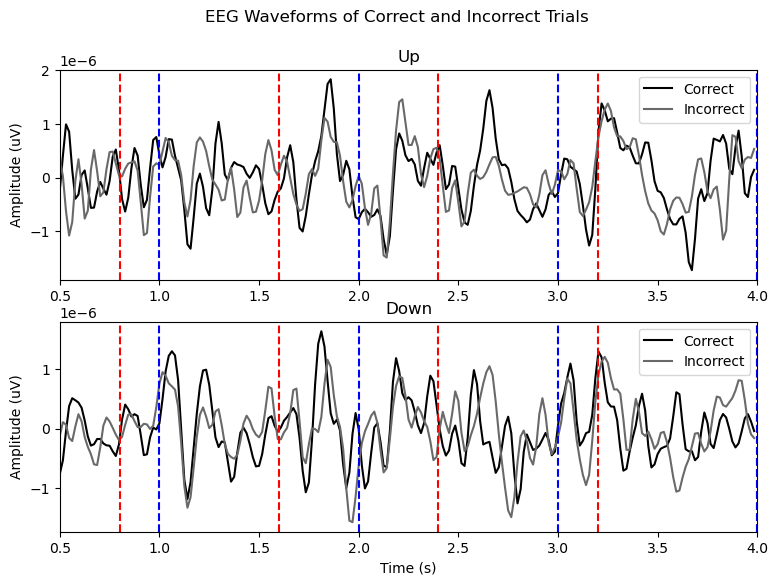

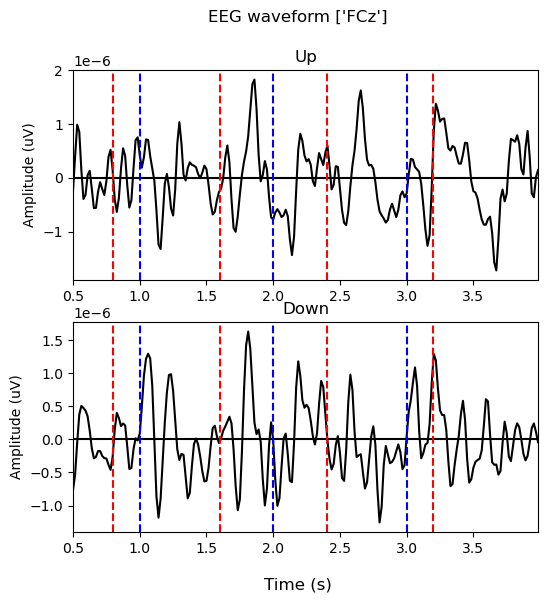

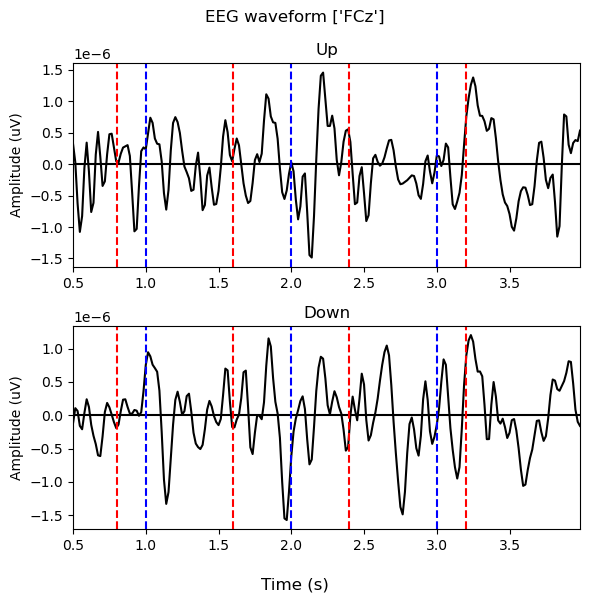

In [22]:
model_name = 'all'
fig, [ax1, ax2] = plt.subplots(2, 1, figsize=(9, 6))

fig1, axs1 = plot_eeg_waveform(dataset[correct_all_idx_sample], plot_channels=['FCz'])
line_up_correct = axs1[0].get_lines()[0]
line_down_correct = axs1[1].get_lines()[0]
fig2, axs2 = plot_eeg_waveform(dataset[incorrect_all_idx], plot_channels=['FCz'])
line_up_incorrect = axs2[0].get_lines()[0]
line_down_incorrect = axs2[1].get_lines()[0]

ax1.plot(line_up_correct.get_xdata(), line_up_correct.get_ydata(), color='k')
ax1.plot(line_up_incorrect.get_xdata(), line_up_incorrect.get_ydata(), color='dimgrey')
for up_onset in np.linspace(0,4,6):
    ax1.axvline(up_onset, color='r', linestyle='--')
for down_onset in np.linspace(0,4,5):
    ax1.axvline(down_onset, color='b', linestyle='--')
ax1.set_title('Up')
ax1.set_ylabel('Amplitude (uV)')
ax1.legend(['Correct', 'Incorrect'])
ax1.set_xlim(0.5, 4.0)

ax2.plot(line_down_correct.get_xdata(), line_down_correct.get_ydata(), color='k')
ax2.plot(line_down_incorrect.get_xdata(), line_down_incorrect.get_ydata(), color='dimgrey')
for up_onset in np.linspace(0,4,6):
    ax2.axvline(up_onset, color='r', linestyle='--')
for down_onset in np.linspace(0,4,5):
    ax2.axvline(down_onset, color='b', linestyle='--')
ax2.set_title('Down')
ax2.set_ylabel('Amplitude (uV)')
ax2.set_xlabel('Time (s)')
ax2.legend(['Correct', 'Incorrect'])
ax2.set_xlim(0.5, 4.0)

fig.suptitle('EEG Waveforms of Correct and Incorrect Trials')
plt.tight_layout()
fig_filename = f"dataset-{dataset_name}_reports-eeg-waveforms-correct-incorrect-FCz_models-{model_name}.png"
fig.savefig(os.path.join(path_dict['reports'], fig_filename), dpi=300)

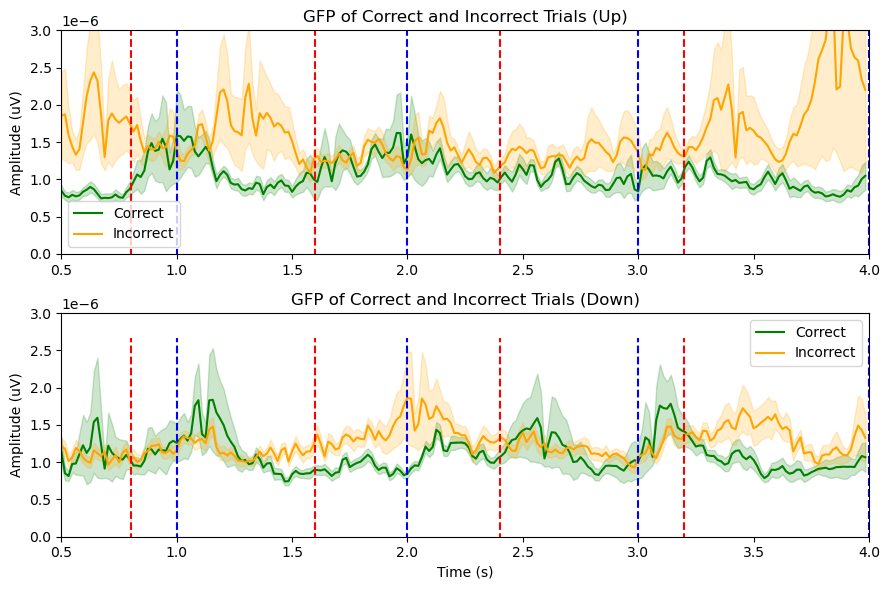

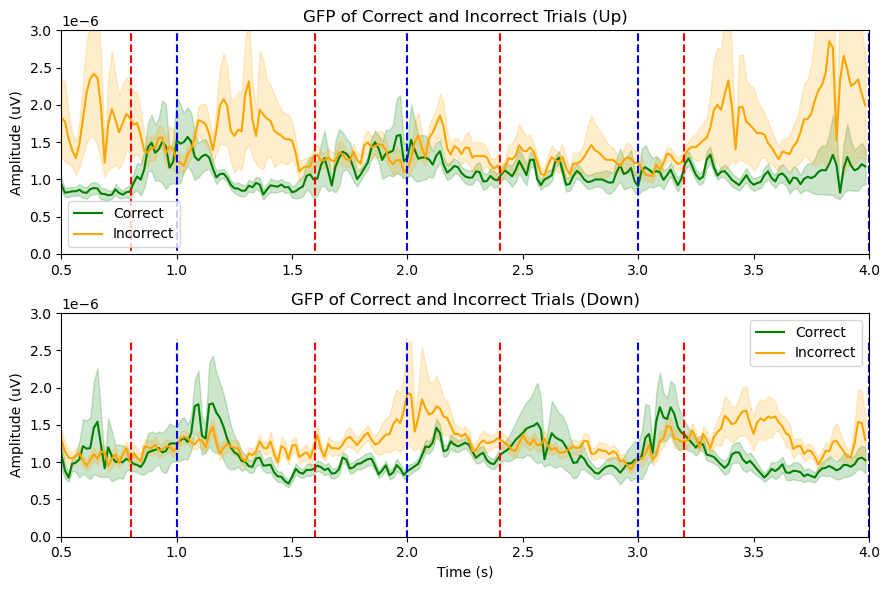

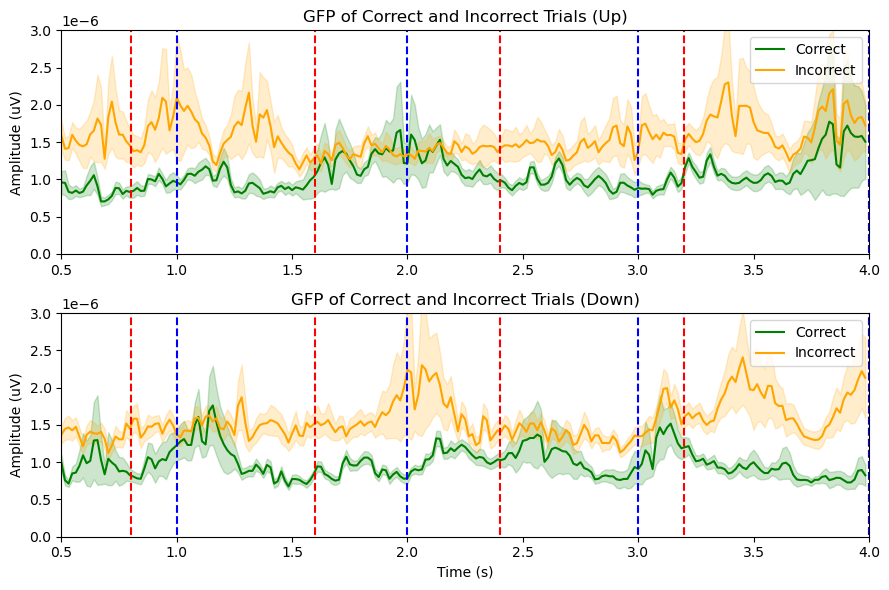

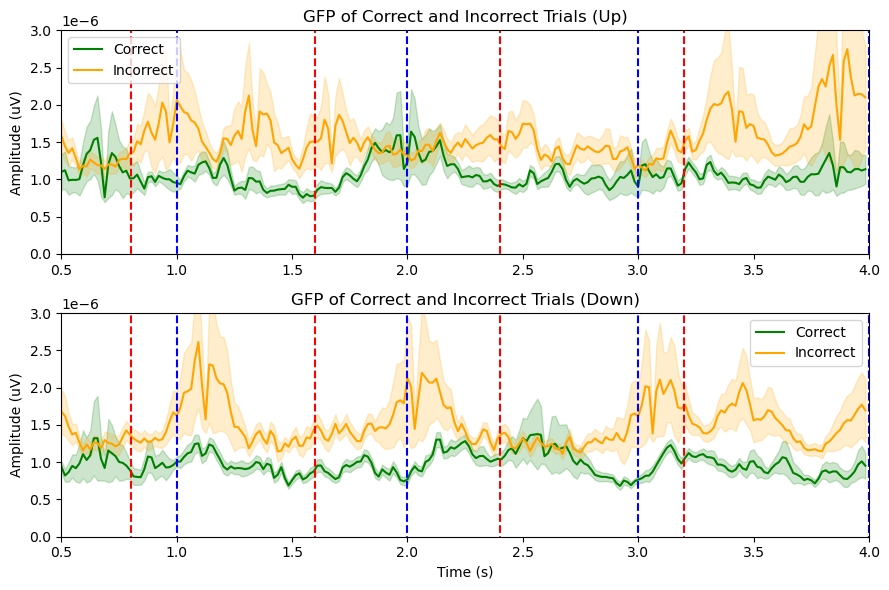

In [23]:
for model_name, df in zip(['logistic-regression', 'svc', 'cnn', 'cnn2'], [results_df_lr, results_df_svc, results_df_cnn, results_df_cnn2]):
    grouped = df.groupby('sub_id')

    # Iterate over each group
    for i, (sub_id, group) in enumerate(grouped):
        correct_up_index = group.index[group['correct'] & (group['label'] == 0)].tolist()
        incorrect_up_index = group.index[~group['correct'] & (group['label'] == 0)].tolist()
        correct_down_index = group.index[group['correct'] & (group['label'] == 1)].tolist()
        incorrect_down_index = group.index[~group['correct'] & (group['label'] == 1)].tolist()

        gfp_correct_up = dataset[correct_up_index].get_eeg().mean(axis=0).std(axis=0)
        gfp_incorrect_up = dataset[incorrect_up_index].get_eeg().mean(axis=0).std(axis=0)
        gfp_correct_down = dataset[correct_down_index].get_eeg().mean(axis=0).std(axis=0)
        gfp_incorrect_down = dataset[incorrect_down_index].get_eeg().mean(axis=0).std(axis=0)
        if i == 0:
            gfp_array = np.zeros((len(grouped), 4, len(gfp_correct_up)))
        gfp_array[i, 0] = gfp_correct_up
        gfp_array[i, 1] = gfp_incorrect_up
        gfp_array[i, 2] = gfp_correct_down
        gfp_array[i, 3] = gfp_incorrect_down

    gfp_mean = gfp_array.mean(axis=0)
    gfp_se = gfp_array.std(axis=0) / np.sqrt(len(grouped))

    # Plot GFP
    time = np.arange(0.5, 4, 1/64)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))

    # Plot for 'up' label
    ax1.plot(time, gfp_mean[0], color='green', label='Correct')
    ax1.fill_between(time, gfp_mean[0] - gfp_se[0], gfp_mean[0] + gfp_se[0], color='green', alpha=0.2)
    ax1.plot(time, gfp_mean[1], color='orange', label='Incorrect')
    ax1.fill_between(time, gfp_mean[1] - gfp_se[1], gfp_mean[1] + gfp_se[1], color='orange', alpha=0.2)
    ymin_up = np.min(gfp_mean[:2]) - np.max(gfp_se[:2])
    ymax_up = np.max(gfp_mean[:2]) + np.max(gfp_se[:2])
    ax1.vlines(np.linspace(0, 4, 6), ymin_up, ymax_up, color='r', linestyle='--')
    ax1.vlines(np.linspace(0, 4, 5), ymin_up, ymax_up, color='b', linestyle='--')
    ax1.set_xlim(0.5, 4)
    ax1.set_ylim(0, 3e-6)
    ax1.set_title('GFP of Correct and Incorrect Trials (Up)')
    ax1.set_ylabel('Amplitude (uV)')
    ax1.legend()

    # Plot for 'down' label
    ax2.plot(time, gfp_mean[2], color='green', label='Correct')
    ax2.fill_between(time, gfp_mean[2] - gfp_se[2], gfp_mean[2] + gfp_se[2], color='green', alpha=0.2)
    ax2.plot(time, gfp_mean[3], color='orange', label='Incorrect')
    ax2.fill_between(time, gfp_mean[3] - gfp_se[3], gfp_mean[3] + gfp_se[3], color='orange', alpha=0.2)
    ymin_down = np.min(gfp_mean[2:]) - np.max(gfp_se[2:])
    ymax_down = np.max(gfp_mean[2:]) + np.max(gfp_se[2:])
    ax2.vlines(np.linspace(0, 4, 6), ymin_down, ymax_down, color='r', linestyle='--')
    ax2.vlines(np.linspace(0, 4, 5), ymin_down, ymax_down, color='b', linestyle='--')
    ax2.set_xlim(0.5, 4)
    ax2.set_ylim(0, 3e-6)
    ax2.set_title('GFP of Correct and Incorrect Trials (Down)')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Amplitude (uV)')
    ax2.legend()

    plt.tight_layout()
    fig_filename = f"dataset-{dataset_name}_reports-eeg-waveform-correct-incorrect-subject-wise-gfp_model-{model_name}.png"
    plt.savefig(os.path.join(path_dict['reports'], fig_filename), dpi=300)

In [26]:
eeg = dataset[correct_up_index].get_eeg().mean(axis=0)
eeg.shape

(64, 224)

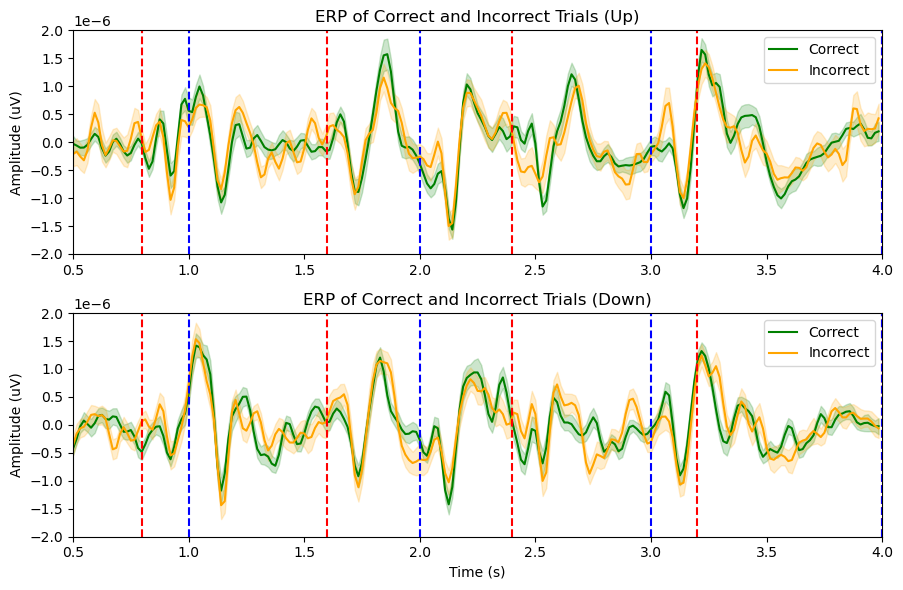

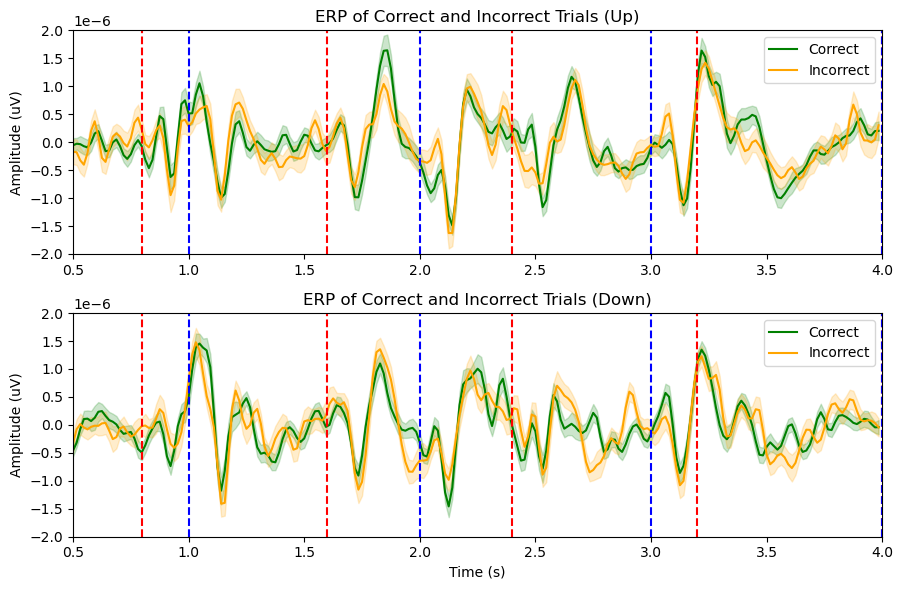

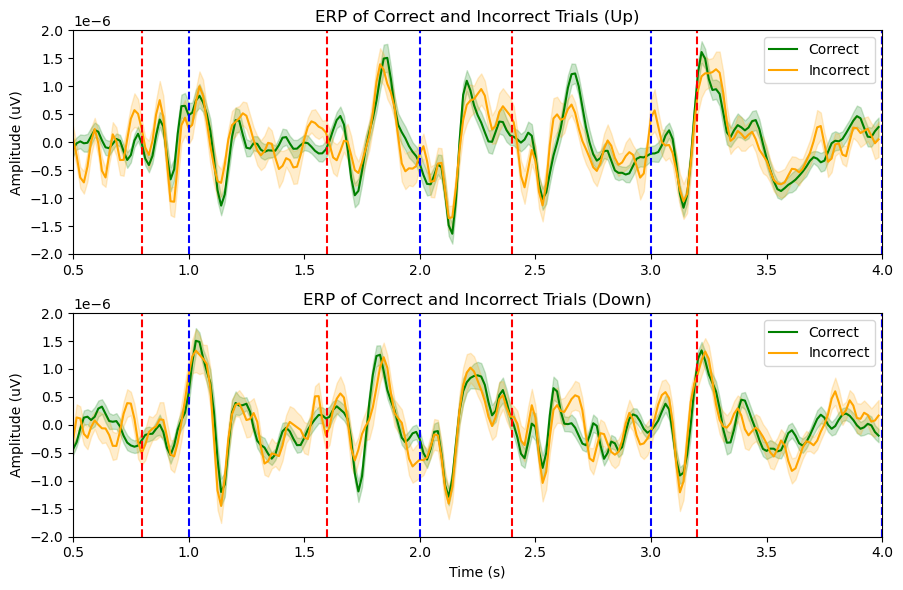

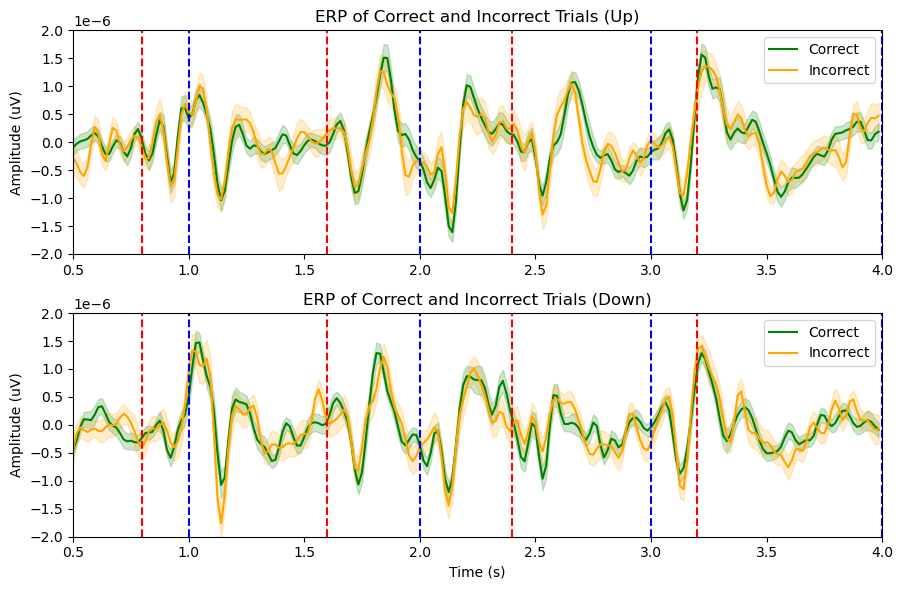

In [30]:
for model_name, df in zip(['logistic-regression', 'svc', 'cnn', 'cnn2'], [results_df_lr, results_df_svc, results_df_cnn, results_df_cnn2]):
    grouped = df.groupby('sub_id')

    # Iterate over each group
    for i, (sub_id, group) in enumerate(grouped):
        correct_up_index = group.index[group['correct'] & (group['label'] == 0)].tolist()
        incorrect_up_index = group.index[~group['correct'] & (group['label'] == 0)].tolist()
        correct_down_index = group.index[group['correct'] & (group['label'] == 1)].tolist()
        incorrect_down_index = group.index[~group['correct'] & (group['label'] == 1)].tolist()

        erp_correct_up = dataset[correct_up_index].get_eeg().mean(axis=0)[46,:]
        erp_incorrect_up = dataset[incorrect_up_index].get_eeg().mean(axis=0)[46,:]
        erp_correct_down = dataset[correct_down_index].get_eeg().mean(axis=0)[46,:]
        erp_incorrect_down = dataset[incorrect_down_index].get_eeg().mean(axis=0)[46,:]
        if i == 0:
            erp_array = np.zeros((len(grouped), 4, len(erp_correct_up)))
        erp_array[i, 0] = erp_correct_up
        erp_array[i, 1] = erp_incorrect_up
        erp_array[i, 2] = erp_correct_down
        erp_array[i, 3] = erp_incorrect_down

    erp_mean = erp_array.mean(axis=0)
    erp_se = erp_array.std(axis=0) / np.sqrt(len(grouped))

    # Plot GFP
    time = np.arange(0.5, 4, 1/64)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))

    # Plot for 'up' label
    ax1.plot(time, erp_mean[0], color='green', label='Correct')
    ax1.fill_between(time, erp_mean[0] - erp_se[0], erp_mean[0] + erp_se[0], color='green', alpha=0.2)
    ax1.plot(time, erp_mean[1], color='orange', label='Incorrect')
    ax1.fill_between(time, erp_mean[1] - erp_se[1], erp_mean[1] + erp_se[1], color='orange', alpha=0.2)
    ymin_up = np.min(erp_mean[:2]) - np.max(erp_se[:2])
    ymax_up = np.max(erp_mean[:2]) + np.max(erp_se[:2])
    ax1.vlines(np.linspace(0, 4, 6), -2e-6, 2e-6, color='r', linestyle='--')
    ax1.vlines(np.linspace(0, 4, 5), -2e-6, 2e-6, color='b', linestyle='--')
    ax1.set_xlim(0.5, 4)
    ax1.set_ylim(-2e-6, 2e-6)
    ax1.set_title('ERP of Correct and Incorrect Trials (Up)')
    ax1.set_ylabel('Amplitude (uV)')
    ax1.legend()

    # Plot for 'down' label
    ax2.plot(time, erp_mean[2], color='green', label='Correct')
    ax2.fill_between(time, erp_mean[2] - erp_se[2], erp_mean[2] + erp_se[2], color='green', alpha=0.2)
    ax2.plot(time, erp_mean[3], color='orange', label='Incorrect')
    ax2.fill_between(time, erp_mean[3] - erp_se[3], erp_mean[3] + erp_se[3], color='orange', alpha=0.2)
    ymin_down = np.min(erp_mean[2:]) - np.max(erp_se[2:])
    ymax_down = np.max(erp_mean[2:]) + np.max(erp_se[2:])
    ax2.vlines(np.linspace(0, 4, 6), -2e-6, 2e-6, color='r', linestyle='--')
    ax2.vlines(np.linspace(0, 4, 5), -2e-6, 2e-6, color='b', linestyle='--')
    ax2.set_xlim(0.5, 4)
    ax2.set_ylim(-2e-6, 2e-6)
    ax2.set_title('ERP of Correct and Incorrect Trials (Down)')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Amplitude (uV)')
    ax2.legend()

    plt.tight_layout()
    fig_filename = f"dataset-{dataset_name}_reports-eeg-waveform-correct-incorrect-subject-wise-FCz_model-{model_name}.png"
    plt.savefig(os.path.join(path_dict['reports'], fig_filename), dpi=300)